# 03 — Modeling

**Goal:** train logistic regression (interpretable baseline) and LightGBM (the workhorse), then evaluate both on the matured test period.

Decisions:
- **LR uses one-hot + standardization** with infrequent-category collapsing for high-cardinality fields.
- **LightGBM uses native categorical handling** — no one-hot blow-up, and NaN is handled natively.
- **LightGBM uses a year-2015 hold-out** within train for early stopping. This is a poor man's walk-forward — we'll do proper expanding-window CV in a follow-up if needed.
- **No calibration here.** Raw scores out of LGBM are not probabilities; we fix that in `04_calibration_profit`.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

from credit_risk import data as cr_data, models as cr_models

MODELS_DIR = Path(__file__).resolve().parents[1] / "models" if "__file__" in dir() else Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## Load processed data

In [2]:
train_df = pd.read_parquet(cr_data.PROCESSED_DIR / "train.parquet")
test_df = pd.read_parquet(cr_data.PROCESSED_DIR / "test.parquet")

META_COLS = ["defaulted", "realized_profit", "issue_d"]
FEATURE_COLS = [c for c in train_df.columns if c not in META_COLS]

# Force non-numeric, non-datetime columns to plain Python `object` strings.
# pandas 3.x's new `str` dtype and PyArrow-backed strings both confuse
# sklearn's SimpleImputer / OneHotEncoder.
for col in train_df.columns:
    if (not pd.api.types.is_numeric_dtype(train_df[col])
            and not pd.api.types.is_datetime64_any_dtype(train_df[col])):
        train_df[col] = train_df[col].astype(object)
        test_df[col] = test_df[col].astype(object)

X_train = train_df[FEATURE_COLS]
y_train = train_df["defaulted"].astype(int)
X_test = test_df[FEATURE_COLS]
y_test = test_df["defaulted"].astype(int)

print(f"Train: {X_train.shape}   default rate: {y_train.mean():.4f}")
print(f"Test:  {X_test.shape}   default rate: {y_test.mean():.4f}")
print(f"Categorical cols ({len(cr_models.categorical_cols(X_train))}): {cr_models.categorical_cols(X_train)}")
print(f"Numeric cols ({len(cr_models.numeric_cols(X_train))})")

Train: (691399, 31)   default rate: 0.1514
Test:  (109235, 31)   default rate: 0.1728
Categorical cols (9): ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'application_type', 'initial_list_status']
Numeric cols (22)


## Train logistic regression

In [3]:
t0 = time.time()
lr_model = cr_models.train_logistic(X_train, y_train)
print(f"LR trained in {time.time() - t0:.1f}s")

# Inspect: how many features did one-hot blow this up to?
n_features_after_ohe = lr_model.named_steps["pre"].transform(X_train.head(1)).shape[1]
print(f"Features after preprocessing: {n_features_after_ohe}")

/Users/rolandtuboly/projects/project_1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LR trained in 6.0s
Features after preprocessing: 142


## Train LightGBM

We carve off the latest training year (2015) as a validation hold-out for early stopping. This is *not* a clean walk-forward — it's just enough signal to stop the boosting at a sensible round.

In [4]:
is_val = train_df["issue_d"].dt.year == 2015
X_tr_es, y_tr_es = X_train[~is_val], y_train[~is_val]
X_val_es, y_val_es = X_train[is_val], y_train[is_val]
print(f"Early-stopping fit set: {len(X_tr_es):,}   val set (2015): {len(X_val_es):,}")

t0 = time.time()
lgb_model = cr_models.train_lightgbm(
    X_tr_es, y_tr_es,
    eval_set=(X_val_es, y_val_es),
    num_boost_round=1000,
)
print(f"LGBM trained in {time.time() - t0:.1f}s  (best iter: {lgb_model.best_iteration})")

Early-stopping fit set: 408,373   val set (2015): 283,026


LGBM trained in 4.0s  (best iter: 155)


## Evaluate on test

In [5]:
def metrics(name, model, X, y):
    p = cr_models.predict_proba(model, X)
    # Top-decile default rate: of the 10% predicted riskiest, what fraction actually default?
    threshold = np.quantile(p, 0.9)
    top_decile_default = y[p >= threshold].mean()
    return {
        "model": name,
        "auc": roc_auc_score(y, p),
        "brier": brier_score_loss(y, p),
        "log_loss": log_loss(y, p),
        "top_decile_default_rate": top_decile_default,
    }

results = pd.DataFrame([
    metrics("logistic", lr_model, X_test, y_test),
    metrics("lightgbm", lgb_model, X_test, y_test),
])
results.round(4)

,model,auc,brier,log_loss,top_decile_default_rate
0,logistic,0.7062,0.1336,0.4269,0.3769
1,lightgbm,0.7106,0.1340,0.4284,0.4001


## Reliability — are these probabilities, or just rankings?

Bin predicted PD into deciles. A well-calibrated model has `mean predicted` ≈ `mean observed` in every bin. LR is usually OK; LGBM is usually overconfident at the extremes.

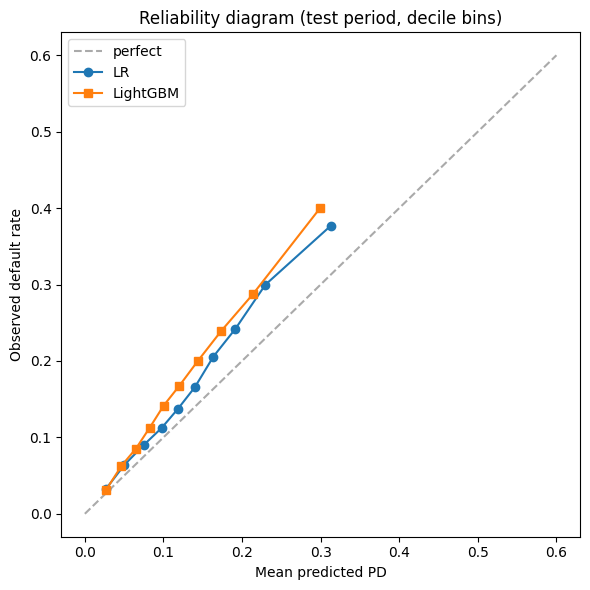

,mean_predicted,mean_observed,n
0,0.026933,0.031124,10924
1,0.046577,0.062803,10923
2,0.064952,0.085225,10924
3,0.082402,0.112515,10923
4,0.100227,0.141523,10924
5,0.120220,0.167536,10923
6,0.144039,0.200403,10923
7,0.173460,0.239198,10924
8,0.213981,0.287558,10923
9,0.299389,0.400128,10924


In [6]:
def reliability(model, X, y, n_bins=10):
    p = cr_models.predict_proba(model, X)
    bins = pd.qcut(p, n_bins, duplicates="drop")
    return (
        pd.DataFrame({"p": p, "y": y.values, "bin": bins})
        .groupby("bin", observed=True)
        .agg(mean_predicted=("p", "mean"), mean_observed=("y", "mean"), n=("y", "size"))
        .reset_index(drop=True)
    )

lr_rel = reliability(lr_model, X_test, y_test)
lgb_rel = reliability(lgb_model, X_test, y_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 0.6], [0, 0.6], color="#aaaaaa", linestyle="--", label="perfect")
ax.plot(lr_rel["mean_predicted"], lr_rel["mean_observed"], marker="o", label="LR")
ax.plot(lgb_rel["mean_predicted"], lgb_rel["mean_observed"], marker="s", label="LightGBM")
ax.set_xlabel("Mean predicted PD")
ax.set_ylabel("Observed default rate")
ax.set_title("Reliability diagram (test period, decile bins)")
ax.legend()
plt.tight_layout()
plt.show()

lgb_rel

## Save the trained models

LR pipeline → joblib (preserves sklearn graph). LightGBM → native text format.

In [7]:
lr_path = MODELS_DIR / "logistic.joblib"
lgb_path = MODELS_DIR / "lightgbm.txt"

joblib.dump(lr_model, lr_path)
lgb_model.save_model(str(lgb_path))

import os
print(f"Wrote {lr_path}  ({os.path.getsize(lr_path)/1e6:.2f} MB)")
print(f"Wrote {lgb_path}  ({os.path.getsize(lgb_path)/1e6:.2f} MB)")

Wrote ../models/logistic.joblib  (0.01 MB)
Wrote ../models/lightgbm.txt  (1.09 MB)


## Takeaways

| metric | LR | LightGBM |
|---|---:|---:|
| AUC | 0.706 | **0.711** |
| Brier | **0.1336** | 0.1340 |
| log loss | **0.4269** | 0.4284 |
| top-decile default rate | 37.7% | **40.0%** |

- **LGBM wins on ranking, LR wins on calibration.** That's expected: LR is built around the log-likelihood objective and is naturally well-calibrated; LightGBM optimizes splits at the leaf level and produces score *rankings* that don't always match probabilities.
- **Top-decile lift ≈ 2.3×.** Base default rate is 17.3%; LGBM's riskiest decile defaults at 40%.
- **LGBM is underconfident at the top.** Reliability bin 9: predicted 30.0%, observed 40.0%. That 10-point gap is exactly what isotonic regression closes in `04_calibration_profit`.
- **Open: walk-forward CV** for robustness — would do expanding-window splits across 2007→2015 to verify the single train/test split isn't a fluke.